In [54]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, month, count, when, avg, desc
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("Adoption_Analysis_India") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

%matplotlib inline



In [55]:
data_path = r"C:\Users\INDIA\Downloads\adoption_dataset_india_2025.csv"

df = spark.read.option("header", True).option("inferSchema", True).csv(data_path)

print(" Data Loaded Successfully")
print("Total Records:", df.count())
df.printSchema()
df.show(5, truncate=False)


✅ Data Loaded Successfully
Total Records: 10102
root
 |-- child_id: string (nullable = true)
 |-- state: string (nullable = true)
 |-- district: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- adoption_type: string (nullable = true)
 |-- adoption_date: date (nullable = true)
 |-- adoptive_parent_type: string (nullable = true)
 |-- orphan_status: string (nullable = true)
 |-- agency_name: string (nullable = true)
 |-- case_number: string (nullable = true)
 |-- registration_center: string (nullable = true)
 |-- socioeconomic_class: string (nullable = true)
 |-- schooling_status: string (nullable = true)
 |-- notes: string (nullable = true)

+--------+-----------+----------------------+---+------+-------------+-------------+--------------------+-------------+---------------+-----------+-------------------+-------------------+----------------+----------------------------------+
|child_id|state      |district              |age|gender|a

In [56]:
cols_to_lower = ["state", "district", "gender", "adoption_type", "adoptive_parent_type",
                 "orphan_status", "agency_name", "registration_center", 
                 "socioeconomic_class", "schooling_status"]

for c in cols_to_lower:
    df = df.withColumn(c, F.lower(F.trim(F.col(c))))

df = df.withColumn("age", F.when(F.col("age").isNull(), F.lit(0)).otherwise(F.col("age")))

df = df.withColumn("adoption_year", year("adoption_date"))
df = df.withColumn("adoption_month", month("adoption_date"))

print(" Data Cleaned and Prepared")
df.show(5)



✅ Data Cleaned and Prepared
+--------+-----------+--------------------+---+------+-------------+-------------+--------------------+-------------+---------------+-----------+-------------------+-------------------+----------------+--------------------+-------------+--------------+
|child_id|      state|            district|age|gender|adoption_type|adoption_date|adoptive_parent_type|orphan_status|    agency_name|case_number|registration_center|socioeconomic_class|schooling_status|               notes|adoption_year|adoption_month|
+--------+-----------+--------------------+---+------+-------------+-------------+--------------------+-------------+---------------+-----------+-------------------+-------------------+----------------+--------------------+-------------+--------------+
| C000001|     kerala|   kerala_district_4| 15|  male|     domestic|   2021-05-16|              couple|    abandoned|  little hearts| CASE-56087|  central_regzone_3|              upper|higher secondary|Participate

In [57]:
print("=== BASIC STATS ===")
df.select(
    F.count("*").alias("Total Records"),
    F.countDistinct("state").alias("Unique States"),
    F.countDistinct("district").alias("Unique Districts"),
    F.countDistinct("agency_name").alias("Agencies Involved")
).show()

print("=== Age Statistics ===")
df.select(
    F.min("age").alias("Min Age"),
    F.max("age").alias("Max Age"),
    F.round(F.avg("age"), 2).alias("Average Age")
).show()


=== BASIC STATS ===
+-------------+-------------+----------------+-----------------+
|Total Records|Unique States|Unique Districts|Agencies Involved|
+-------------+-------------+----------------+-----------------+
|        10102|           16|              80|                6|
+-------------+-------------+----------------+-----------------+

=== Age Statistics ===
+-------+-------+-----------+
|Min Age|Max Age|Average Age|
+-------+-------+-----------+
|      1|     18|       9.57|
+-------+-------+-----------+



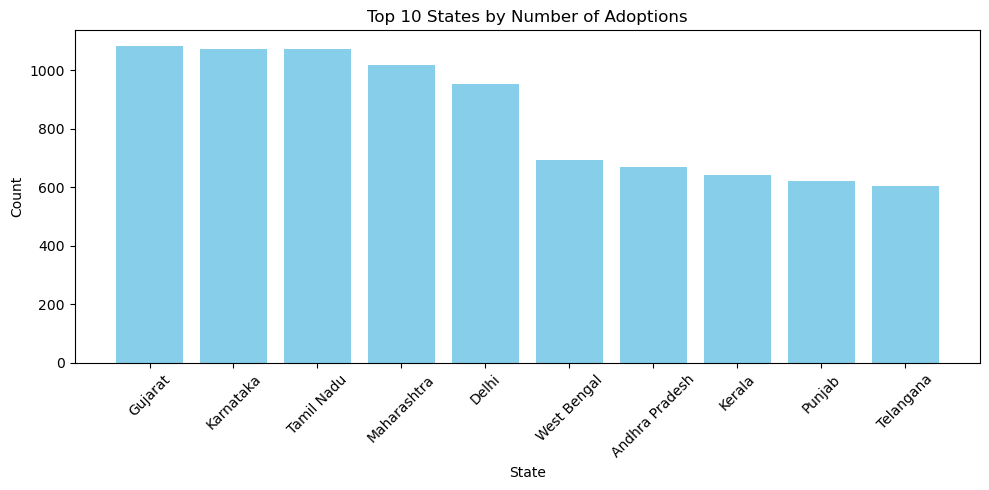

+--------------+-----+
|         state|count|
+--------------+-----+
|       gujarat| 1082|
|     karnataka| 1074|
|    tamil nadu| 1072|
|   maharashtra| 1019|
|         delhi|  952|
|   west bengal|  694|
|andhra pradesh|  668|
|        kerala|  643|
|        punjab|  621|
|     telangana|  605|
+--------------+-----+
only showing top 10 rows


In [58]:
state_counts = df.groupBy("state").count().orderBy(desc("count"))
top_states_pd = state_counts.limit(10).toPandas()

plt.figure(figsize=(10,5))
plt.bar(top_states_pd["state"].str.title(), top_states_pd["count"], color="skyblue")
plt.title("Top 10 States by Number of Adoptions")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

state_counts.show(10)


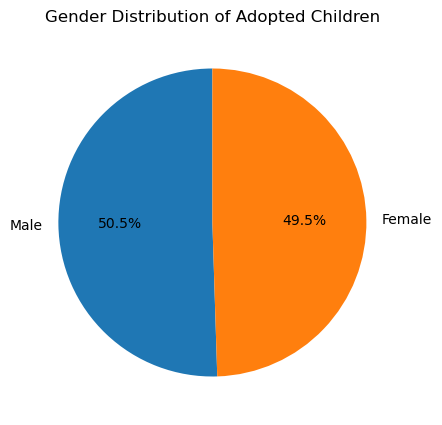

+------+-----+
|gender|count|
+------+-----+
|  male| 5102|
|female| 5000|
+------+-----+



In [59]:
gender_dist = df.groupBy("gender").count().orderBy(desc("count"))
gender_pd = gender_dist.toPandas()

plt.figure(figsize=(5,5))
plt.pie(gender_pd["count"], labels=gender_pd["gender"].str.title(), autopct='%1.1f%%', startangle=90)
plt.title("Gender Distribution of Adopted Children")
plt.show()

gender_dist.show()


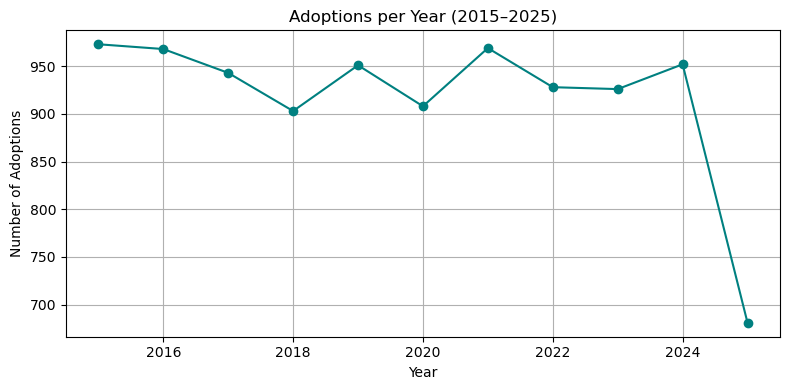

+-------------+-----+
|adoption_year|count|
+-------------+-----+
|         2015|  973|
|         2016|  968|
|         2017|  943|
|         2018|  903|
|         2019|  951|
|         2020|  908|
|         2021|  969|
|         2022|  928|
|         2023|  926|
|         2024|  952|
|         2025|  681|
+-------------+-----+



In [60]:
trend = df.groupBy("adoption_year").count().orderBy("adoption_year")
trend_pd = trend.toPandas()

plt.figure(figsize=(8,4))
plt.plot(trend_pd["adoption_year"], trend_pd["count"], marker='o', color='teal')
plt.title("Adoptions per Year (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Adoptions")
plt.grid(True)
plt.tight_layout()
plt.show()

trend.show()


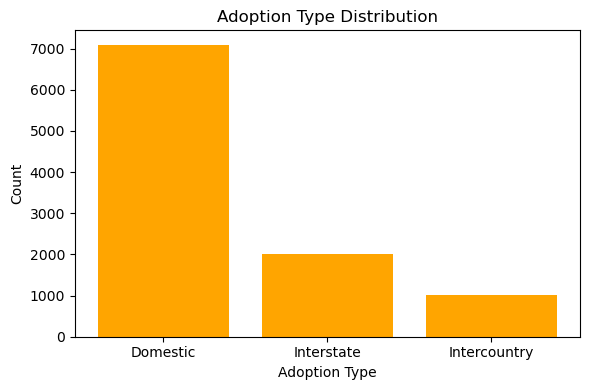

+-------------+-----+
|adoption_type|count|
+-------------+-----+
|     domestic| 7090|
|   interstate| 2009|
| intercountry| 1003|
+-------------+-----+



In [61]:
type_counts = df.groupBy("adoption_type").count().orderBy(desc("count"))
type_pd = type_counts.toPandas()

plt.figure(figsize=(6,4))
plt.bar(type_pd["adoption_type"].str.title(), type_pd["count"], color="orange")
plt.title("Adoption Type Distribution")
plt.xlabel("Adoption Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

type_counts.show()


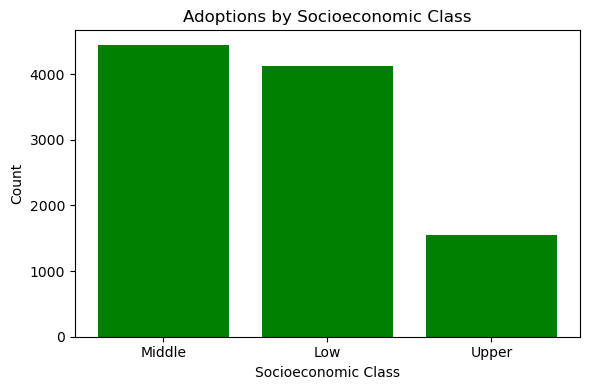

+-------------------+-----+
|socioeconomic_class|count|
+-------------------+-----+
|             middle| 4443|
|                low| 4115|
|              upper| 1544|
+-------------------+-----+



In [62]:
socio_df = df.groupBy("socioeconomic_class").count().orderBy(desc("count"))
socio_pd = socio_df.toPandas()

plt.figure(figsize=(6,4))
plt.bar(socio_pd["socioeconomic_class"].str.title(), socio_pd["count"], color="green")
plt.title("Adoptions by Socioeconomic Class")
plt.xlabel("Socioeconomic Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

socio_df.show()


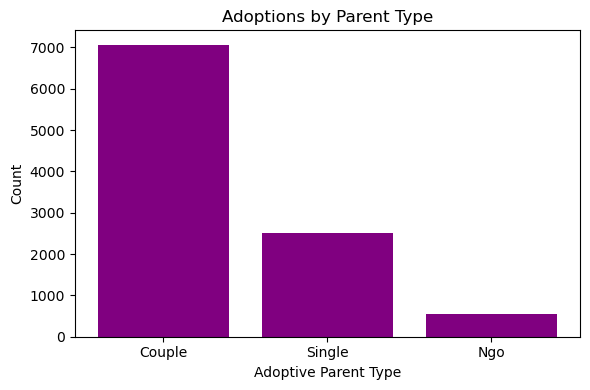

+--------------------+-----+
|adoptive_parent_type|count|
+--------------------+-----+
|              couple| 7059|
|              single| 2501|
|                 ngo|  542|
+--------------------+-----+



In [63]:
parent_df = df.groupBy("adoptive_parent_type").count().orderBy(desc("count"))
parent_pd = parent_df.toPandas()

plt.figure(figsize=(6,4))
plt.bar(parent_pd["adoptive_parent_type"].str.title(), parent_pd["count"], color="purple")
plt.title("Adoptions by Parent Type")
plt.xlabel("Adoptive Parent Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

parent_df.show()


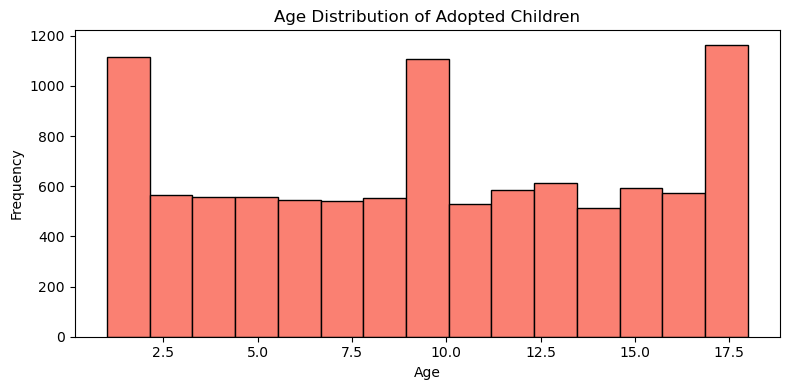

In [64]:
ages_pd = df.select("age").toPandas()

plt.figure(figsize=(8,4))
plt.hist(ages_pd["age"], bins=15, color="salmon", edgecolor="black")
plt.title("Age Distribution of Adopted Children")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


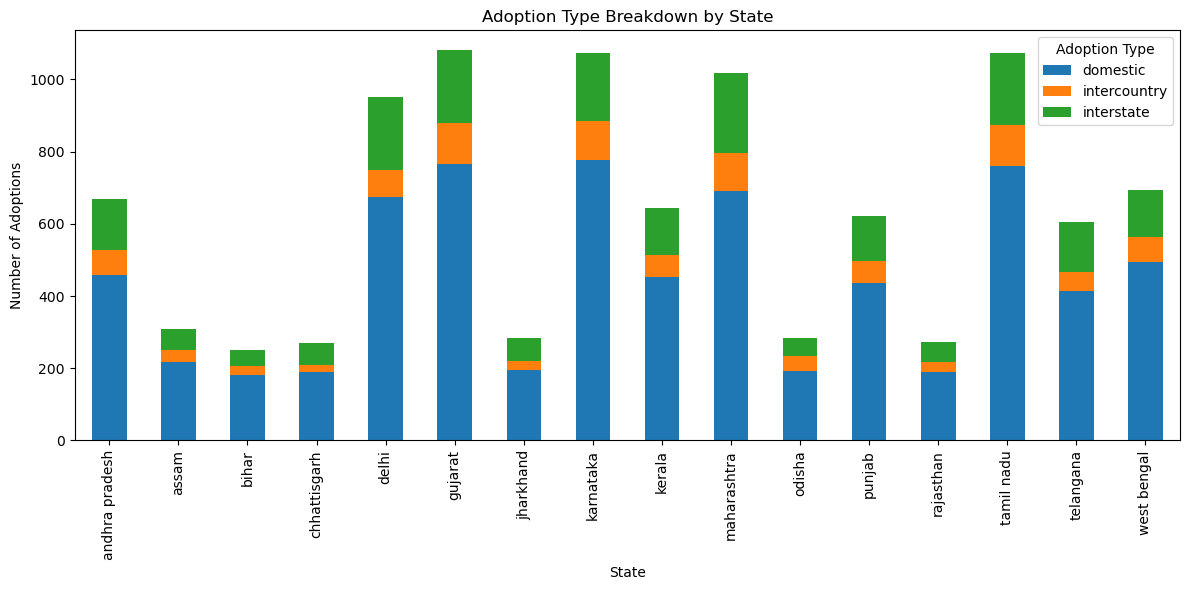

In [65]:
cross = df.groupBy("state", "adoption_type").count().orderBy("state")
cross_pd = cross.toPandas().pivot(index="state", columns="adoption_type", values="count").fillna(0)

cross_pd.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Adoption Type Breakdown by State")
plt.xlabel("State")
plt.ylabel("Number of Adoptions")
plt.legend(title="Adoption Type")
plt.tight_layout()
plt.show()


In [66]:
print("=== Quick Insights Summary ===")

top_state = state_counts.first()
print(f"Highest Adoption State: {top_state['state'].title()} ({top_state['count']} adoptions)")

most_common_type = type_counts.first()
print(f" Most Common Adoption Type: {most_common_type['adoption_type'].title()} ({most_common_type['count']})")

avg_age = df.select(F.round(F.avg("age"), 2).alias("avg_age")).collect()[0]["avg_age"]
print(f"👶 Average Age of Adopted Children: {avg_age} years")

gender_split = gender_pd.set_index("gender")["count"].to_dict()
print(f"⚧ Gender Split: {gender_split}")


=== Quick Insights Summary ===
Highest Adoption State: Gujarat (1082 adoptions)
 Most Common Adoption Type: Domestic (7090)
👶 Average Age of Adopted Children: 9.57 years
⚧ Gender Split: {'male': 5102, 'female': 5000}


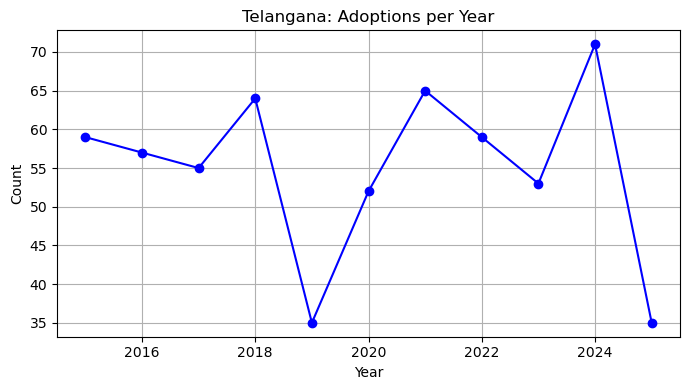

+-------------+-----+
|adoption_year|count|
+-------------+-----+
|         2015|   59|
|         2016|   57|
|         2017|   55|
|         2018|   64|
|         2019|   35|
|         2020|   52|
|         2021|   65|
|         2022|   59|
|         2023|   53|
|         2024|   71|
|         2025|   35|
+-------------+-----+



In [67]:
import seaborn as sns
tel = df.filter(col("state") == "telangana")
tel_trend = tel.groupBy("adoption_year").count().orderBy("adoption_year")
tel_trend_pd = tel_trend.toPandas()

plt.figure(figsize=(7,4))
plt.plot(tel_trend_pd["adoption_year"], tel_trend_pd["count"], marker='o', color='blue')
plt.title("Telangana: Adoptions per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

tel_trend.show()


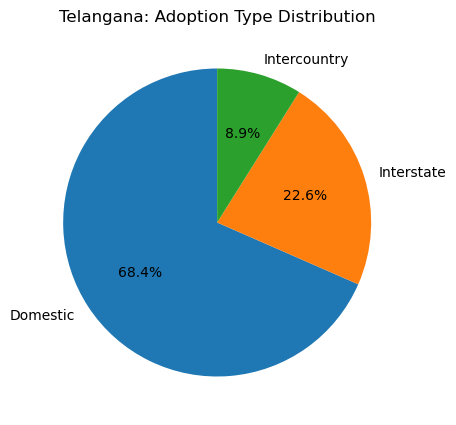

+-------------+-----+
|adoption_type|count|
+-------------+-----+
|     domestic|  414|
|   interstate|  137|
| intercountry|   54|
+-------------+-----+



In [68]:
tel_type = tel.groupBy("adoption_type").count().orderBy(desc("count"))
tel_type_pd = tel_type.toPandas()

plt.figure(figsize=(5,5))
plt.pie(tel_type_pd["count"], labels=tel_type_pd["adoption_type"].str.title(), autopct="%1.1f%%", startangle=90)
plt.title("Telangana: Adoption Type Distribution")
plt.show()

tel_type.show()


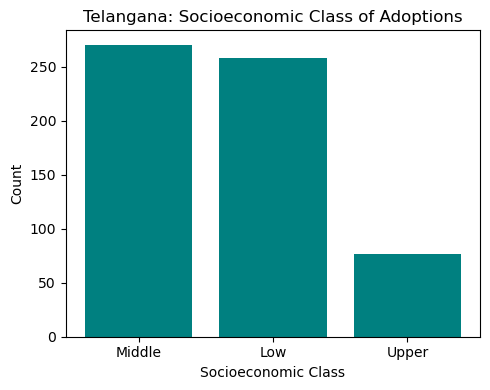

+-------------------+-----+
|socioeconomic_class|count|
+-------------------+-----+
|             middle|  270|
|                low|  258|
|              upper|   77|
+-------------------+-----+



In [69]:
tel_socio = tel.groupBy("socioeconomic_class").count().orderBy(desc("count"))
tel_socio_pd = tel_socio.toPandas()

plt.figure(figsize=(5,4))
plt.bar(tel_socio_pd["socioeconomic_class"].str.title(), tel_socio_pd["count"], color="teal")
plt.title("Telangana: Socioeconomic Class of Adoptions")
plt.xlabel("Socioeconomic Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

tel_socio.show()


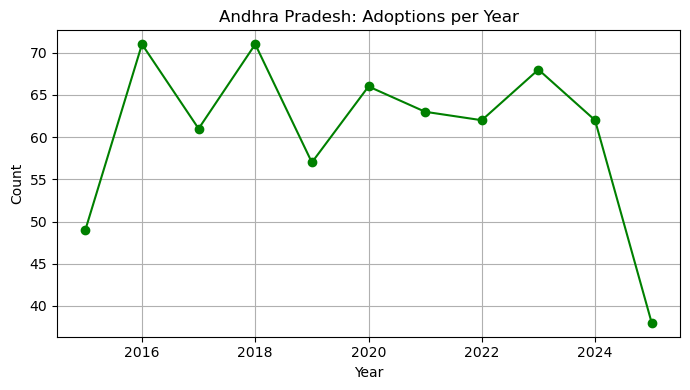

+-------------+-----+
|adoption_year|count|
+-------------+-----+
|         2015|   49|
|         2016|   71|
|         2017|   61|
|         2018|   71|
|         2019|   57|
|         2020|   66|
|         2021|   63|
|         2022|   62|
|         2023|   68|
|         2024|   62|
|         2025|   38|
+-------------+-----+



In [70]:
ap = df.filter(col("state") == "andhra pradesh")
ap_trend = ap.groupBy("adoption_year").count().orderBy("adoption_year")
ap_trend_pd = ap_trend.toPandas()

plt.figure(figsize=(7,4))
plt.plot(ap_trend_pd["adoption_year"], ap_trend_pd["count"], marker='o', color='green')
plt.title("Andhra Pradesh: Adoptions per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

ap_trend.show()


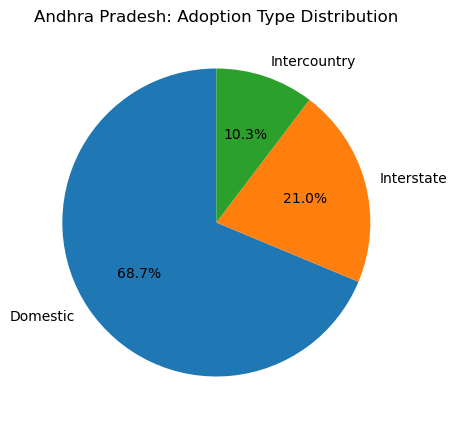

+-------------+-----+
|adoption_type|count|
+-------------+-----+
|     domestic|  459|
|   interstate|  140|
| intercountry|   69|
+-------------+-----+



In [71]:
ap_type = ap.groupBy("adoption_type").count().orderBy(desc("count"))
ap_type_pd = ap_type.toPandas()

plt.figure(figsize=(5,5))
plt.pie(ap_type_pd["count"], labels=ap_type_pd["adoption_type"].str.title(), autopct="%1.1f%%", startangle=90)
plt.title("Andhra Pradesh: Adoption Type Distribution")
plt.show()

ap_type.show()


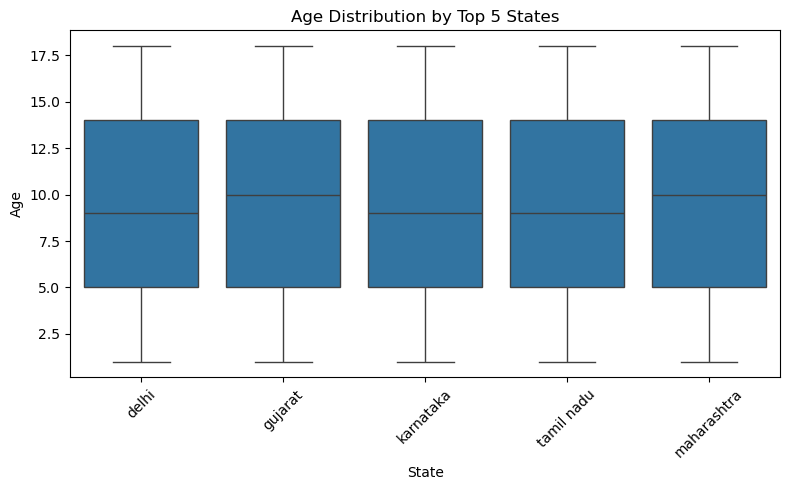

In [72]:
# select top 5 states
top5_states = [row['state'] for row in state_counts.limit(5).collect()]
subset = df.filter(col("state").isin(top5_states)).select("state", "age").toPandas()

plt.figure(figsize=(8,5))
import seaborn as sns
sns.boxplot(data=subset, x="state", y="age")
plt.title("Age Distribution by Top 5 States")
plt.xlabel("State")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


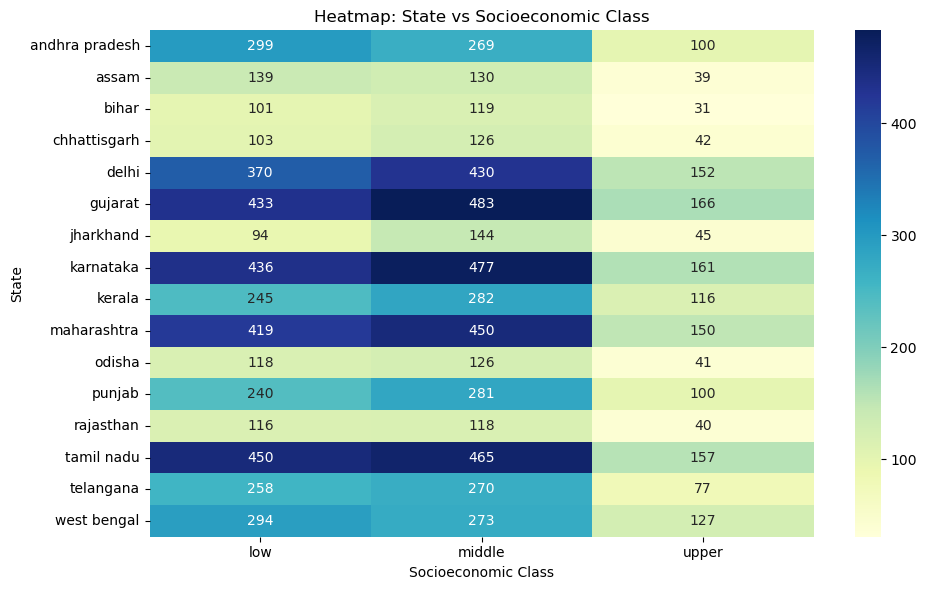

In [73]:
cross_socio = df.groupBy("state", "socioeconomic_class").count().toPandas()
pivot = cross_socio.pivot(index="state", columns="socioeconomic_class", values="count").fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap: State vs Socioeconomic Class")
plt.xlabel("Socioeconomic Class")
plt.ylabel("State")
plt.tight_layout()
plt.show()


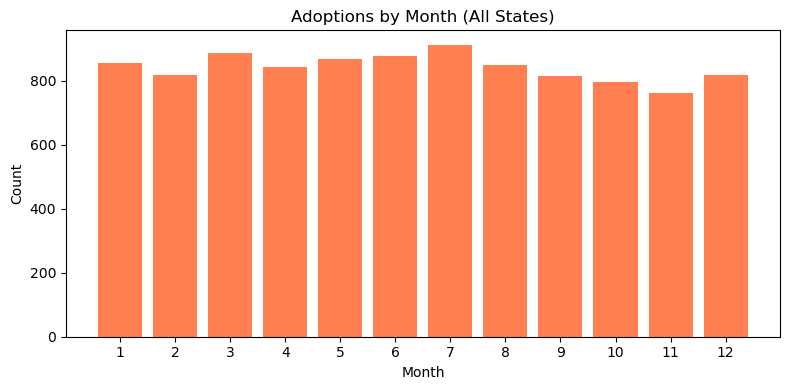

In [74]:
month_pd = df.groupBy("adoption_month").count().orderBy("adoption_month").toPandas()
plt.figure(figsize=(8,4))
plt.bar(month_pd["adoption_month"], month_pd["count"], color="coral")
plt.title("Adoptions by Month (All States)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()


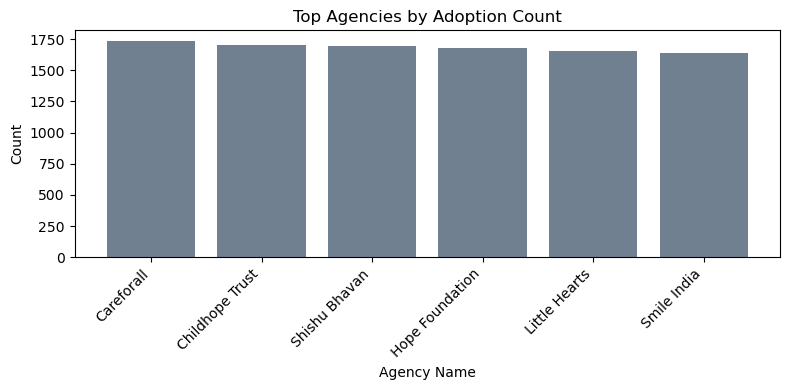

+---------------+-----+
|    agency_name|count|
+---------------+-----+
|     careforall| 1734|
|childhope trust| 1702|
|  shishu bhavan| 1694|
|hope foundation| 1678|
|  little hearts| 1652|
|    smile india| 1642|
+---------------+-----+



In [75]:
agency_counts = df.groupBy("agency_name").count().orderBy(desc("count"))
agency_pd = agency_counts.limit(8).toPandas()

plt.figure(figsize=(8,4))
plt.bar(agency_pd["agency_name"].str.title(), agency_pd["count"], color="slategrey")
plt.title("Top Agencies by Adoption Count")
plt.xlabel("Agency Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

agency_counts.show(8)
